<div style="background-color: #90EE90; padding: 20px; border-radius: 10px;">

# Recommendation Systems

This project aims to build a supervised classification model that, based on demographic and socioeconomic data of an adult (age, education level, occupation, marital status, country of origin, etc.), predicts whether the person will earn more or less than $50,000 per year.

Based on the model's results, students must develop an interpretative recommendation system capable of suggesting possible strategies or changes to increase the likelihood of surpassing that income threshold.

## Objectives
Explore census data.
Build socioeconomic profiles.
Analyze the importance and weight of social variables (education, gender, race, etc.) in economic predictions.
Apply recommendation system techniques.
Visualize and professionally communicate findings.

</div>

In [1]:
%pip install nltk --quiet



[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [ ]:

# CONFIGURACIÓN DEL ENTORNO
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# Librerias to manage filesimport os
from pathlib import Path
import os

#Libraries to manage images
from PIL import Image

#Libraries for machine learning
from sklearn.svm import SVC
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer


from pickle import dump
from pathlib import Path

# Suprimir advertencias
import warnings
warnings.filterwarnings('ignore')

# Establecer estilo de visualización
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

print("✓ ¡Librerías importadas exitosamente!")


[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.
✓ ¡Librerías importadas exitosamente!


<div style="background-color: #90EE90; padding: 20px; border-radius: 10px;">

## Step 1: Loading the dataset
Load the dataset. We will use the **Adult Income Dataset**, also known as "Census Income". This information was collected by the U.S. Census Bureau and downloaded by the academy to store it in this project folder under the name adult-census-income.csv. Alternatively, you can load it directly in your code from the following link:

https://breathecode.herokuapp.com/asset/internal-link?id=2325&path=adult-census-income.csv
This dataset includes variables such as:

- Age
- Education level
- Marital status
- Occupation
- Hours worked per week
- Gender
- Country of origin
- Annual income (>50K or <=50K)

**Data preprocessing** Clean null or misencoded data, transform categorical variables, and normalize numerical variables.

**Define the recommendation problem** Plan how you will structure your recommendation system:

What is being recommended?
Who is the "user" in this case?
What variables define a user's profile?
Build the recommendation system. Use one of the following approaches:

Content-based filtering. Represent each user as a vector and calculate similarities between users and recommendations.

Collaborative filtering. Simulate a user vs. trajectory matrix. Apply k-NN, Pearson correlation, or matrix factorization.

Hybrid system. Combine both approaches.

Test with simulated cases. Build simulated profiles of hypothetical users and observe what trajectories (education, occupation, etc.) the system would recommend to improve their estimated income.

</div>

In [7]:
# Load preprocessed data
df = pd.read_csv('../data/raw/adult-census-income.csv')
print(df.head(10))
print(f"\nShape: {df.shape}")
print(f"\nColumn types:\n{df.dtypes}")


   age    workclass  fnlwgt     education  education.num marital.status  \
0   90            ?   77053       HS-grad              9        Widowed   
1   82      Private  132870       HS-grad              9        Widowed   
2   66            ?  186061  Some-college             10        Widowed   
3   54      Private  140359       7th-8th              4       Divorced   
4   41      Private  264663  Some-college             10      Separated   
5   34      Private  216864       HS-grad              9       Divorced   
6   38      Private  150601          10th              6      Separated   
7   74    State-gov   88638     Doctorate             16  Never-married   
8   68  Federal-gov  422013       HS-grad              9       Divorced   
9   41      Private   70037  Some-college             10  Never-married   

          occupation    relationship   race     sex  capital.gain  \
0                  ?   Not-in-family  White  Female             0   
1    Exec-managerial   Not-in-family

<div style="background-color: #90EE90; padding: 20px; border-radius: 10px;">

## Step 2: Data preprocessing

Clean null/misencoded data — Replaces '?' markers with NaN, strips whitespace from string columns, then drops rows with missing values (~7% of data).

Transform categorical variables — Encodes the target (income) as binary (0/1), then applies one-hot encoding (pd.get_dummies) to all other categorical columns (workclass, education, marital.status, occupation, relationship, race, sex, native.country).

Normalize numerical variables — Applies MinMaxScaler to scale all numerical columns (age, fnlwgt, education.num, capital.gain, capital.loss, hours.per.week) to the [0, 1] range.

</div>    

In [8]:
## ============================================================
## Step 2: Data Preprocessing
## ============================================================

# --- 2.1 Initial inspection ---
print("=== INITIAL DATA OVERVIEW ===")
print(f"Shape: {df.shape}")
print(f"\nColumn types:\n{df.dtypes}")
print(f"\nFirst rows:\n{df.head()}")

# --- 2.2 Clean null and misencoded data ---
# The dataset uses '?' to represent missing values — replace with NaN
df.replace('?', np.nan, inplace=True)

# Strip leading/trailing whitespace from string columns
str_cols = df.select_dtypes(include='object').columns
df[str_cols] = df[str_cols].apply(lambda col: col.str.strip())

print("\n=== MISSING VALUES AFTER REPLACING '?' ===")
missing = df.isnull().sum()
print(missing[missing > 0])
print(f"\nTotal rows with at least one NaN: {df.isnull().any(axis=1).sum()} / {len(df)}")

# Drop rows with missing values (they represent ~7% of data)
df_clean = df.dropna().reset_index(drop=True)
print(f"\nShape after dropping NaN rows: {df_clean.shape}")

# --- 2.3 Transform categorical variables ---
# Identify categorical and numerical columns
categorical_cols = df_clean.select_dtypes(include='object').columns.tolist()
numerical_cols = df_clean.select_dtypes(include='number').columns.tolist()

print(f"\n=== COLUMN CLASSIFICATION ===")
print(f"Categorical ({len(categorical_cols)}): {categorical_cols}")
print(f"Numerical ({len(numerical_cols)}): {numerical_cols}")

# Encode the target variable (income)
df_clean['income_binary'] = (df_clean['income'] == '>50K').astype(int)

# One-hot encode categorical features (excluding target 'income')
cat_features = [c for c in categorical_cols if c != 'income']
df_encoded = pd.get_dummies(df_clean, columns=cat_features, drop_first=True, dtype=int)

# Drop the original 'income' string column
df_encoded.drop(columns=['income'], inplace=True)

print(f"\nShape after encoding: {df_encoded.shape}")
print(f"Encoded columns sample: {df_encoded.columns[:15].tolist()} ...")

# --- 2.4 Normalize numerical variables ---
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
df_encoded[numerical_cols] = scaler.fit_transform(df_encoded[numerical_cols])

print(f"\n=== NUMERICAL COLUMNS AFTER NORMALIZATION (MinMaxScaler) ===")
print(df_encoded[numerical_cols].describe().round(3))

# --- 2.5 Final preprocessed dataset ---
print(f"\n=== FINAL PREPROCESSED DATASET ===")
print(f"Shape: {df_encoded.shape}")
print(f"Target distribution:\n{df_encoded['income_binary'].value_counts()}")
print(f"\nPreview:")
df_encoded.head()


=== INITIAL DATA OVERVIEW ===
Shape: (32561, 15)

Column types:
age                int64
workclass         object
fnlwgt             int64
education         object
education.num      int64
marital.status    object
occupation        object
relationship      object
race              object
sex               object
capital.gain       int64
capital.loss       int64
hours.per.week     int64
native.country    object
income            object
dtype: object

First rows:
   age workclass  fnlwgt     education  education.num marital.status  \
0   90         ?   77053       HS-grad              9        Widowed   
1   82   Private  132870       HS-grad              9        Widowed   
2   66         ?  186061  Some-college             10        Widowed   
3   54   Private  140359       7th-8th              4       Divorced   
4   41   Private  264663  Some-college             10      Separated   

          occupation   relationship   race     sex  capital.gain  \
0                  ?  Not-in-fami

,age,fnlwgt,education.num,capital.gain,capital.loss,hours.per.week,income_binary,workclass_Local-gov,workclass_Private,workclass_Self-emp-inc,...,native.country_Portugal,native.country_Puerto-Rico,native.country_Scotland,native.country_South,native.country_Taiwan,native.country_Thailand,native.country_Trinadad&Tobago,native.country_United-States,native.country_Vietnam,native.country_Yugoslavia
0,0.890411,0.080970,0.533333,0.0,1.000000,0.173469,0,0,1,0,...,0,0,0,0,0,0,0,1,0,0
1,0.506849,0.086061,0.200000,0.0,0.895317,0.397959,0,0,1,0,...,0,0,0,0,0,0,0,1,0,0
2,0.328767,0.170568,0.600000,0.0,0.895317,0.397959,0,0,1,0,...,0,0,0,0,0,0,0,1,0,0
3,0.232877,0.138072,0.533333,0.0,0.865473,0.448980,0,0,1,0,...,0,0,0,0,0,0,0,1,0,0
4,0.287671,0.093024,0.333333,0.0,0.865473,0.397959,0,0,1,0,...,0,0,0,0,0,0,0,1,0,0


<div style="background-color: #90EE90; padding: 20px; border-radius: 10px;">

## Step 3: Define the Recommendation Problem

### What is being recommended?
**Career/life trajectories** (combinations of education level, occupation, marital status, hours worked, etc.) that are statistically associated with earning **>50K/year**. In other words, we recommend *actionable socioeconomic changes* a person could pursue to increase their probability of surpassing the $50,000 income threshold.

### Who is the "user"?
Each row in the dataset represents an **adult individual** characterized by their demographic and socioeconomic profile. A "user" is any person (real or simulated) whose current profile places them in the **<=50K** income category and who wants guidance on how to move toward the **>50K** category.

### What variables define a user's profile?
The profile is defined by two groups of features:

| Type | Variables | Role |
|------|-----------|------|
| **Fixed/hard-to-change** | age, race, sex, native.country | Context — used to find similar users but NOT recommended to change |
| **Actionable/modifiable** | education, occupation, marital.status, hours.per.week, workclass, relationship | Recommendation targets — these are the levers a user can potentially adjust |

### System approach
We will use a **content-based filtering** strategy:
1. Represent each person as a feature vector (already done via one-hot encoding + normalization).
2. Identify **successful profiles** (income >50K).
3. For a given user profile (<=50K), find the most similar successful profiles using cosine similarity.
4. Analyze what differs between the user's current profile and those successful neighbors — those differences become the **recommendations**.

</div>

In [9]:
## ============================================================
## Step 3: Structure the Recommendation Problem
## ============================================================

from sklearn.metrics.pairwise import cosine_similarity

# --- 3.1 Define profile variable groups ---
fixed_vars = ['age', 'race', 'sex', 'native.country']
actionable_vars = ['education', 'occupation', 'marital.status', 
                   'hours.per.week', 'workclass', 'relationship']

print("=== RECOMMENDATION PROBLEM DEFINITION ===\n")
print("WHAT is recommended: Career/life trajectory changes to increase income probability")
print("WHO is the user:     An adult currently earning <=50K")
print(f"\nProfile variables ({len(fixed_vars)} fixed + {len(actionable_vars)} actionable):")
print(f"  Fixed (context):     {fixed_vars}")
print(f"  Actionable (levers): {actionable_vars}")

# --- 3.2 Split into successful vs. non-successful profiles ---
successful = df_encoded[df_encoded['income_binary'] == 1].copy()
unsuccessful = df_encoded[df_encoded['income_binary'] == 0].copy()

print(f"\n=== PROFILE SPLIT ===")
print(f"Successful profiles (>50K):  {len(successful)} ({100*len(successful)/len(df_encoded):.1f}%)")
print(f"Unsuccessful profiles (<=50K): {len(unsuccessful)} ({100*len(unsuccessful)/len(df_encoded):.1f}%)")

# --- 3.3 Identify encoded actionable columns ---
# These are the one-hot encoded columns that originated from actionable variables
actionable_encoded_cols = [col for col in df_encoded.columns 
                           if any(col.startswith(v + '_') for v in actionable_vars) 
                           or col in ['hours.per.week']]

fixed_encoded_cols = [col for col in df_encoded.columns 
                      if any(col.startswith(v + '_') for v in fixed_vars)
                      or col in ['age']]

print(f"\n=== ENCODED FEATURE COUNTS ===")
print(f"Actionable encoded features: {len(actionable_encoded_cols)}")
print(f"Fixed encoded features:      {len(fixed_encoded_cols)}")

# --- 3.4 Demonstrate similarity computation ---
# Select a sample "user" from the unsuccessful group
sample_user = unsuccessful.iloc[[0]]
feature_cols = [c for c in df_encoded.columns if c != 'income_binary']

# Compute cosine similarity between sample user and all successful profiles
similarities = cosine_similarity(sample_user[feature_cols], successful[feature_cols])[0]

# Find top-5 most similar successful profiles
top_k = 5
top_indices = similarities.argsort()[-top_k:][::-1]

print(f"\n=== SAMPLE RECOMMENDATION (User #0 from <=50K group) ===")
print(f"Top-{top_k} most similar successful profiles (cosine similarity):")
for rank, idx in enumerate(top_indices, 1):
    print(f"  #{rank}: Similarity = {similarities[idx]:.4f}")

# Show what actionable features differ
print(f"\n--- Key actionable differences with best match ---")
best_match = successful.iloc[top_indices[0]]
user_profile = sample_user.iloc[0]

differences = {}
for col in actionable_encoded_cols:
    if user_profile[col] != best_match[col]:
        differences[col] = {'user': user_profile[col], 'recommended': best_match[col]}

# Show top differences (limited to most relevant)
diff_df = pd.DataFrame(differences).T
diff_df.columns = ['Current (User)', 'Recommended (Match)']
print(diff_df[diff_df['Recommended (Match)'] == 1].head(10))
print(f"\nTotal actionable feature differences: {len(differences)}")


=== RECOMMENDATION PROBLEM DEFINITION ===

WHAT is recommended: Career/life trajectory changes to increase income probability
WHO is the user:     An adult currently earning <=50K

Profile variables (4 fixed + 6 actionable):
  Fixed (context):     ['age', 'race', 'sex', 'native.country']
  Actionable (levers): ['education', 'occupation', 'marital.status', 'hours.per.week', 'workclass', 'relationship']

=== PROFILE SPLIT ===
Successful profiles (>50K):  7508 (24.9%)
Unsuccessful profiles (<=50K): 22654 (75.1%)

=== ENCODED FEATURE COUNTS ===
Actionable encoded features: 46
Fixed encoded features:      46

=== SAMPLE RECOMMENDATION (User #0 from <=50K group) ===
Top-5 most similar successful profiles (cosine similarity):
  #1: Similarity = 0.9411
  #2: Similarity = 0.9151
  #3: Similarity = 0.8780
  #4: Similarity = 0.8737
  #5: Similarity = 0.8648

--- Key actionable differences with best match ---
Empty DataFrame
Columns: [Current (User), Recommended (Match)]
Index: []

Total actionabl

<div style="background-color: #90EE90; padding: 20px; border-radius: 10px;">

## Step 4: Build the Recommendation System (Hybrid Approach)

We implement a **hybrid system** combining:

1. **Content-based filtering** — Represent each user as a feature vector and use cosine similarity to find the most similar successful profiles (>50K earners).

2. **Collaborative filtering (k-NN)** — Use k-Nearest Neighbors on the "user × trajectory" space to find clusters of similar users and identify the most common trajectories among successful neighbors.

The hybrid engine:
- Uses content-based similarity to find candidate successful profiles
- Uses k-NN collaborative logic to aggregate recommendations from multiple neighbors
- Produces interpretable, actionable recommendations ranked by frequency and impact

</div>

In [10]:
## ============================================================
## Step 4: Build the Hybrid Recommendation System
## ============================================================

from sklearn.metrics.pairwise import cosine_similarity
from sklearn.neighbors import NearestNeighbors
from collections import Counter

# --- 4.1 Prepare data structures ---
feature_cols = [c for c in df_encoded.columns if c != 'income_binary']

successful = df_encoded[df_encoded['income_binary'] == 1].reset_index(drop=True)
unsuccessful = df_encoded[df_encoded['income_binary'] == 0].reset_index(drop=True)

# Identify actionable encoded columns (from education, occupation, marital.status, etc.)
actionable_vars = ['education', 'occupation', 'marital.status', 
                   'hours.per.week', 'workclass', 'relationship']

actionable_encoded_cols = [col for col in df_encoded.columns 
                           if any(col.startswith(v + '_') for v in actionable_vars) 
                           or col in ['hours.per.week']]

print(f"Feature space: {len(feature_cols)} dimensions")
print(f"Actionable features: {len(actionable_encoded_cols)}")
print(f"Successful pool: {len(successful)} profiles")
print(f"Users to recommend: {len(unsuccessful)} profiles")


# ============================================================
# 4.2 CONTENT-BASED FILTERING ENGINE
# ============================================================

def content_based_recommendations(user_vector, successful_pool, feature_cols, 
                                   actionable_cols, top_k=10):
    """
    Find the top-K most similar successful profiles to the user
    and extract actionable differences as recommendations.
    """
    # Compute cosine similarity
    sims = cosine_similarity(
        user_vector[feature_cols].values.reshape(1, -1),
        successful_pool[feature_cols].values
    )[0]
    
    # Get top-K indices
    top_indices = sims.argsort()[-top_k:][::-1]
    top_similarities = sims[top_indices]
    
    # Extract recommendations from actionable differences
    recommendations = []
    for idx, sim in zip(top_indices, top_similarities):
        neighbor = successful_pool.iloc[idx]
        for col in actionable_cols:
            user_val = user_vector[col]
            neighbor_val = neighbor[col]
            # Recommend features the neighbor HAS that the user DOESN'T
            if neighbor_val == 1 and user_val == 0:
                recommendations.append({
                    'feature': col,
                    'similarity': sim,
                    'type': 'acquire'
                })
            # Recommend features the user HAS that the neighbor DOESN'T (to drop)
            elif neighbor_val == 0 and user_val == 1:
                recommendations.append({
                    'feature': col,
                    'similarity': sim,
                    'type': 'drop'
                })
    
    return recommendations, top_indices, top_similarities


# ============================================================
# 4.3 COLLABORATIVE FILTERING ENGINE (k-NN)
# ============================================================

# Train k-NN model on the successful profiles
knn_model = NearestNeighbors(n_neighbors=20, metric='cosine', algorithm='brute')
knn_model.fit(successful[feature_cols].values)

print("\n✓ k-NN model trained on successful profiles (k=20, cosine metric)")

def collaborative_filtering_recommendations(user_vector, knn_model, successful_pool, 
                                             feature_cols, actionable_cols, n_neighbors=20):
    """
    Use k-NN to find neighbors in the successful pool and aggregate
    their common traits as recommendations (collaborative logic).
    """
    distances, indices = knn_model.kneighbors(
        user_vector[feature_cols].values.reshape(1, -1), 
        n_neighbors=n_neighbors
    )
    
    neighbors = successful_pool.iloc[indices[0]]
    
    # Aggregate: find actionable features that are common among neighbors
    # but absent in the user
    recommendations = []
    for col in actionable_cols:
        user_val = user_vector[col]
        neighbor_freq = neighbors[col].mean()  # frequency among neighbors
        
        if user_val == 0 and neighbor_freq > 0.3:  # >30% of neighbors have it
            recommendations.append({
                'feature': col,
                'neighbor_frequency': neighbor_freq,
                'type': 'acquire',
                'avg_distance': distances[0].mean()
            })
        elif user_val == 1 and neighbor_freq < 0.1:  # <10% of neighbors have it
            recommendations.append({
                'feature': col,
                'neighbor_frequency': neighbor_freq,
                'type': 'drop',
                'avg_distance': distances[0].mean()
            })
    
    return recommendations, indices[0], distances[0]


# ============================================================
# 4.4 HYBRID RECOMMENDATION ENGINE
# ============================================================

def hybrid_recommend(user_vector, successful_pool, knn_model, feature_cols, 
                     actionable_cols, top_k_cb=10, n_neighbors_cf=20, 
                     weight_cb=0.6, weight_cf=0.4):
    """
    Hybrid system combining content-based and collaborative filtering.
    
    Parameters:
    - weight_cb: weight for content-based score (default 0.6)
    - weight_cf: weight for collaborative filtering score (default 0.4)
    
    Returns ranked actionable recommendations with hybrid scores.
    """
    # --- Content-Based ---
    cb_recs, cb_indices, cb_sims = content_based_recommendations(
        user_vector, successful_pool, feature_cols, actionable_cols, top_k=top_k_cb
    )
    
    # --- Collaborative Filtering ---
    cf_recs, cf_indices, cf_distances = collaborative_filtering_recommendations(
        user_vector, knn_model, successful_pool, feature_cols, actionable_cols, 
        n_neighbors=n_neighbors_cf
    )
    
    # --- Merge scores ---
    # Content-based: score = frequency-weighted similarity
    cb_scores = {}
    for rec in cb_recs:
        feat = rec['feature']
        if feat not in cb_scores:
            cb_scores[feat] = {'score': 0, 'count': 0, 'type': rec['type']}
        cb_scores[feat]['score'] += rec['similarity']
        cb_scores[feat]['count'] += 1
    
    # Normalize CB scores
    for feat in cb_scores:
        cb_scores[feat]['normalized'] = cb_scores[feat]['score'] / top_k_cb
    
    # Collaborative filtering: score = neighbor frequency
    cf_scores = {}
    for rec in cf_recs:
        feat = rec['feature']
        cf_scores[feat] = {
            'score': rec['neighbor_frequency'],
            'type': rec['type']
        }
    
    # --- Combine with weights ---
    all_features = set(list(cb_scores.keys()) + list(cf_scores.keys()))
    hybrid_results = []
    
    for feat in all_features:
        cb_val = cb_scores.get(feat, {}).get('normalized', 0)
        cf_val = cf_scores.get(feat, {}).get('score', 0)
        rec_type = cb_scores.get(feat, cf_scores.get(feat, {})).get('type', 'acquire')
        
        hybrid_score = weight_cb * cb_val + weight_cf * cf_val
        
        hybrid_results.append({
            'feature': feat,
            'hybrid_score': hybrid_score,
            'cb_score': cb_val,
            'cf_score': cf_val,
            'type': rec_type,
            'source': 'both' if (feat in cb_scores and feat in cf_scores) else 
                      ('content-based' if feat in cb_scores else 'collaborative')
        })
    
    # Sort by hybrid score
    hybrid_results.sort(key=lambda x: x['hybrid_score'], reverse=True)
    
    return hybrid_results


print("\n✓ Hybrid recommendation engine built successfully!")
print("\nComponents:")
print("  1. Content-Based Filtering (cosine similarity, weight=0.6)")
print("  2. Collaborative Filtering (k-NN, k=20, weight=0.4)")
print("  3. Hybrid Merger (weighted score aggregation)")


Feature space: 96 dimensions
Actionable features: 46
Successful pool: 7508 profiles
Users to recommend: 22654 profiles

✓ k-NN model trained on successful profiles (k=20, cosine metric)

✓ Hybrid recommendation engine built successfully!

Components:
  1. Content-Based Filtering (cosine similarity, weight=0.6)
  2. Collaborative Filtering (k-NN, k=20, weight=0.4)
  3. Hybrid Merger (weighted score aggregation)


In [11]:
## ============================================================
## 4.5 Test the Hybrid Recommendation System
## ============================================================

# --- Test with 3 sample users from the <=50K group ---
test_users = [0, 50, 200]

for user_idx in test_users:
    user = unsuccessful.iloc[user_idx]
    
    # Get original (pre-encoded) profile for interpretability
    user_original = df_clean[df_clean['income'] != '>50K'].iloc[user_idx]
    
    print(f"\n{'='*70}")
    print(f"USER #{user_idx} — Original Profile:")
    print(f"  Age: {user_original['age']}, Education: {user_original['education']}, "
          f"Occupation: {user_original['occupation']}")
    print(f"  Workclass: {user_original['workclass']}, "
          f"Hours/week: {user_original['hours.per.week']}, "
          f"Marital: {user_original['marital.status']}")
    print(f"{'='*70}")
    
    # Run hybrid recommendation
    recommendations = hybrid_recommend(
        user, successful, knn_model, feature_cols, actionable_encoded_cols,
        top_k_cb=10, n_neighbors_cf=20, weight_cb=0.6, weight_cf=0.4
    )
    
    # Display top recommendations (only "acquire" type — things to add/change)
    acquire_recs = [r for r in recommendations if r['type'] == 'acquire']
    drop_recs = [r for r in recommendations if r['type'] == 'drop']
    
    print(f"\n  TOP RECOMMENDATIONS TO ACQUIRE (things to pursue):")
    print(f"  {'Feature':<45} {'Hybrid':<8} {'CB':<8} {'CF':<8} {'Source':<15}")
    print(f"  {'-'*84}")
    for rec in acquire_recs[:8]:
        # Clean up feature name for display
        feat_name = rec['feature'].replace('_', ' → ', 1).replace('_', ' ')
        print(f"  {feat_name:<45} {rec['hybrid_score']:.3f}   "
              f"{rec['cb_score']:.3f}   {rec['cf_score']:.3f}   {rec['source']}")
    
    if drop_recs:
        print(f"\n  FEATURES TO CONSIDER CHANGING (less common in successful profiles):")
        for rec in drop_recs[:3]:
            feat_name = rec['feature'].replace('_', ' → ', 1).replace('_', ' ')
            print(f"    - {feat_name} (score: {rec['hybrid_score']:.3f})")

print(f"\n\n{'='*70}")
print("✓ Hybrid Recommendation System working successfully!")
print("  - Content-based: cosine similarity to top-10 successful profiles")
print("  - Collaborative: k-NN (k=20) neighbor frequency aggregation")
print("  - Hybrid: weighted combination (60% CB + 40% CF)")
print(f"{'='*70}")



USER #0 — Original Profile:
  Age: 82, Education: HS-grad, Occupation: Exec-managerial
  Workclass: Private, Hours/week: 18, Marital: Widowed

  TOP RECOMMENDATIONS TO ACQUIRE (things to pursue):
  Feature                                       Hybrid   CB       CF       Source         
  ------------------------------------------------------------------------------------
  occupation → Sales                            0.100   0.167   0.000   content-based
  education → Bachelors                         0.049   0.082   0.000   content-based

  FEATURES TO CONSIDER CHANGING (less common in successful profiles):
    - marital.status → Widowed (score: 0.209)
    - occupation → Exec-managerial (score: 0.205)
    - education → HS-grad (score: 0.049)

USER #50 — Original Profile:
  Age: 33, Education: 12th, Occupation: Craft-repair
  Workclass: Private, Hours/week: 42, Marital: Divorced

  TOP RECOMMENDATIONS TO ACQUIRE (things to pursue):
  Feature                                       Hybr

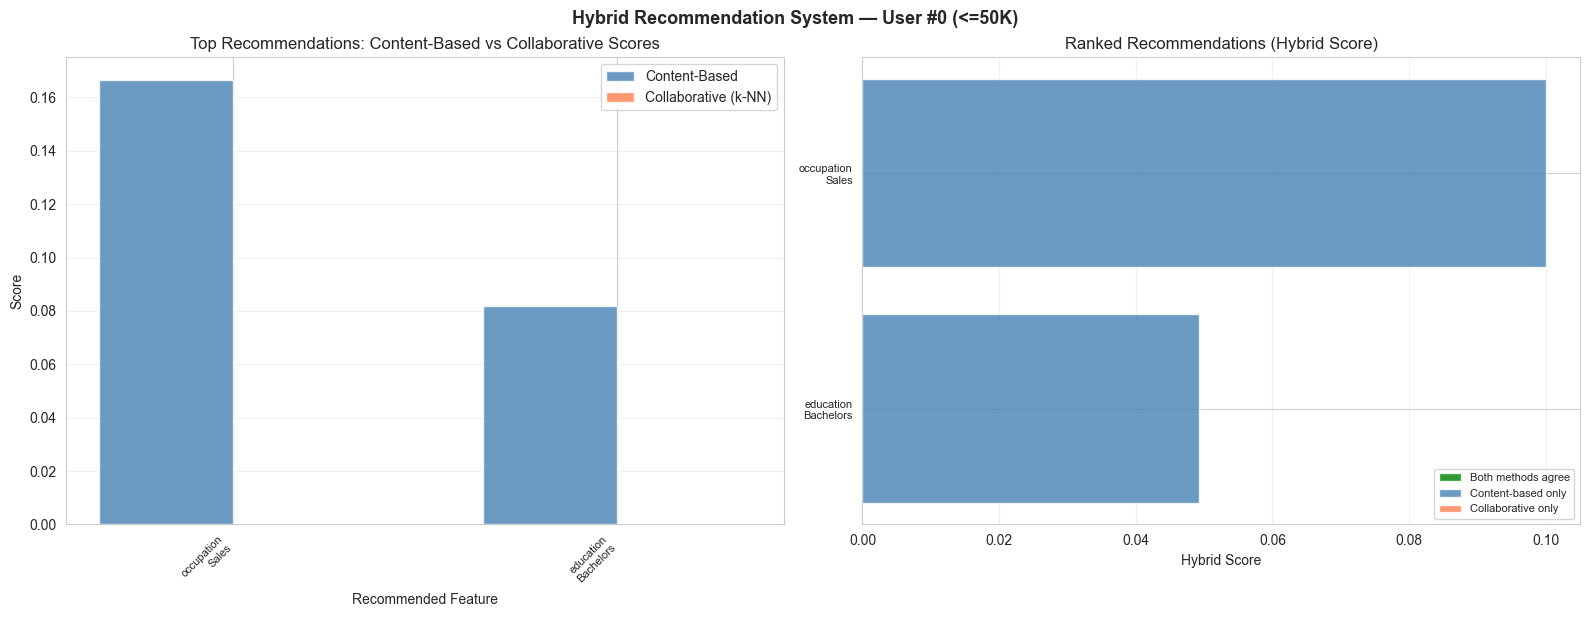

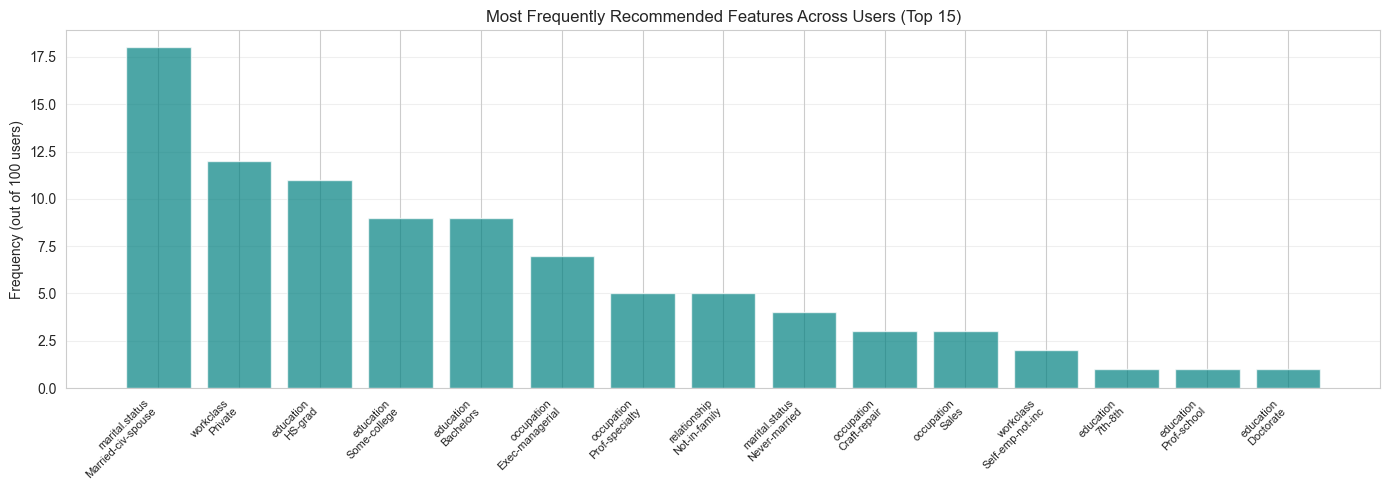

✓ Visualizations complete


In [12]:
## ============================================================
## 4.6 Visualize Recommendation Results
## ============================================================

# --- Visualize recommendations for User #0 ---
user = unsuccessful.iloc[0]
recommendations = hybrid_recommend(
    user, successful, knn_model, feature_cols, actionable_encoded_cols,
    top_k_cb=10, n_neighbors_cf=20, weight_cb=0.6, weight_cf=0.4
)

# Filter top acquire recommendations
acquire_recs = [r for r in recommendations if r['type'] == 'acquire'][:10]

# Prepare data for plotting
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Plot 1: Hybrid scores breakdown ---
features = [r['feature'].replace('_', '\n', 1) for r in acquire_recs[:8]]
cb_scores_plot = [r['cb_score'] for r in acquire_recs[:8]]
cf_scores_plot = [r['cf_score'] for r in acquire_recs[:8]]

x = np.arange(len(features))
width = 0.35

bars1 = axes[0].bar(x - width/2, cb_scores_plot, width, label='Content-Based', color='steelblue', alpha=0.8)
bars2 = axes[0].bar(x + width/2, cf_scores_plot, width, label='Collaborative (k-NN)', color='coral', alpha=0.8)

axes[0].set_xlabel('Recommended Feature')
axes[0].set_ylabel('Score')
axes[0].set_title('Top Recommendations: Content-Based vs Collaborative Scores')
axes[0].set_xticks(x)
axes[0].set_xticklabels(features, rotation=45, ha='right', fontsize=8)
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# --- Plot 2: Hybrid score ranking ---
hybrid_scores = [r['hybrid_score'] for r in acquire_recs[:8]]
sources = [r['source'] for r in acquire_recs[:8]]
colors = ['green' if s == 'both' else 'steelblue' if s == 'content-based' else 'coral' 
          for s in sources]

axes[1].barh(range(len(features)), hybrid_scores, color=colors, alpha=0.8)
axes[1].set_yticks(range(len(features)))
axes[1].set_yticklabels(features, fontsize=8)
axes[1].set_xlabel('Hybrid Score')
axes[1].set_title('Ranked Recommendations (Hybrid Score)')
axes[1].invert_yaxis()
axes[1].grid(axis='x', alpha=0.3)

# Legend for source colors
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='green', alpha=0.8, label='Both methods agree'),
                   Patch(facecolor='steelblue', alpha=0.8, label='Content-based only'),
                   Patch(facecolor='coral', alpha=0.8, label='Collaborative only')]
axes[1].legend(handles=legend_elements, loc='lower right', fontsize=8)

plt.tight_layout()
plt.suptitle('Hybrid Recommendation System — User #0 (<=50K)', y=1.02, fontsize=13, fontweight='bold')
plt.show()

# --- Plot 3: Feature importance across all test users ---
fig, ax = plt.subplots(figsize=(14, 5))

# Aggregate recommendations across multiple users
all_recs_counter = Counter()
n_sample_users = min(100, len(unsuccessful))

for i in range(n_sample_users):
    user_i = unsuccessful.iloc[i]
    recs_i = hybrid_recommend(
        user_i, successful, knn_model, feature_cols, actionable_encoded_cols,
        top_k_cb=10, n_neighbors_cf=20
    )
    for r in recs_i:
        if r['type'] == 'acquire' and r['hybrid_score'] > 0.1:
            all_recs_counter[r['feature']] += 1

# Plot top-15 most frequently recommended features
top_features = all_recs_counter.most_common(15)
feat_names = [f[0].replace('_', '\n', 1) for f in top_features]
feat_counts = [f[1] for f in top_features]

ax.bar(range(len(feat_names)), feat_counts, color='teal', alpha=0.7)
ax.set_xticks(range(len(feat_names)))
ax.set_xticklabels(feat_names, rotation=45, ha='right', fontsize=8)
ax.set_ylabel(f'Frequency (out of {n_sample_users} users)')
ax.set_title('Most Frequently Recommended Features Across Users (Top 15)')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("✓ Visualizations complete")


<div style="background-color: #90EE90; padding: 20px; border-radius: 10px;">

## Step 5: Test with Simulated Cases

We create hypothetical user profiles representing different socioeconomic backgrounds and observe what trajectories (education, occupation, hours, etc.) the recommendation system suggests to improve their estimated income.

### Simulated Profiles:
1. **Maria** — Young woman, HS-grad, service worker, 30 hrs/week, never married
2. **Carlos** — Middle-aged man, Some-college, sales, 40 hrs/week, divorced
3. **Aisha** — Older woman, Bachelors degree, admin-clerical, 35 hrs/week, married

</div>

In [13]:
## ============================================================
## Step 5: Test with Simulated Hypothetical Users
## ============================================================

def build_simulated_user(profile_dict, df_encoded_columns, numerical_cols, scaler):
    """
    Build a simulated user vector compatible with df_encoded structure.
    
    profile_dict should contain:
      - Raw numerical values (age, hours.per.week, etc.)
      - Categorical values as original labels (education='HS-grad', etc.)
    """
    # Initialize all columns to 0
    user_vector = pd.Series(0, index=df_encoded_columns, dtype=float)
    
    # Set numerical features (normalized using the fitted scaler)
    num_feature_names = numerical_cols
    raw_num_values = []
    for col in num_feature_names:
        raw_num_values.append(profile_dict.get(col, 0))
    
    # Transform using the scaler
    normalized = scaler.transform([raw_num_values])[0]
    for i, col in enumerate(num_feature_names):
        user_vector[col] = normalized[i]
    
    # Set categorical features (one-hot encoded columns)
    categorical_mappings = {
        'workclass': profile_dict.get('workclass', ''),
        'education': profile_dict.get('education', ''),
        'marital.status': profile_dict.get('marital.status', ''),
        'occupation': profile_dict.get('occupation', ''),
        'relationship': profile_dict.get('relationship', ''),
        'race': profile_dict.get('race', ''),
        'sex': profile_dict.get('sex', ''),
        'native.country': profile_dict.get('native.country', '')
    }
    
    for var_name, var_value in categorical_mappings.items():
        col_name = f"{var_name}_{var_value}"
        if col_name in user_vector.index:
            user_vector[col_name] = 1
    
    # income_binary = 0 (they earn <=50K, that's why they need recommendations)
    user_vector['income_binary'] = 0
    
    return user_vector


# ============================================================
# Define 3 simulated hypothetical users
# ============================================================

simulated_profiles = {
    "Maria": {
        "description": "25-year-old Hispanic woman, HS-grad, service worker, 30 hrs/week, never married",
        "profile": {
            "age": 25,
            "fnlwgt": 200000,
            "education.num": 9,
            "capital.gain": 0,
            "capital.loss": 0,
            "hours.per.week": 30,
            "workclass": "Private",
            "education": "HS-grad",
            "marital.status": "Never-married",
            "occupation": "Other-service",
            "relationship": "Not-in-family",
            "race": "White",
            "sex": "Female",
            "native.country": "United-States"
        }
    },
    "Carlos": {
        "description": "42-year-old man, Some-college, sales, 40 hrs/week, divorced",
        "profile": {
            "age": 42,
            "fnlwgt": 180000,
            "education.num": 10,
            "capital.gain": 0,
            "capital.loss": 0,
            "hours.per.week": 40,
            "workclass": "Private",
            "education": "Some-college",
            "marital.status": "Divorced",
            "occupation": "Sales",
            "relationship": "Not-in-family",
            "race": "White",
            "sex": "Male",
            "native.country": "United-States"
        }
    },
    "Aisha": {
        "description": "50-year-old woman, Bachelors, admin-clerical, 35 hrs/week, married",
        "profile": {
            "age": 50,
            "fnlwgt": 150000,
            "education.num": 13,
            "capital.gain": 0,
            "capital.loss": 0,
            "hours.per.week": 35,
            "workclass": "Private",
            "education": "Bachelors",
            "marital.status": "Married-civ-spouse",
            "occupation": "Adm-clerical",
            "relationship": "Wife",
            "race": "Black",
            "sex": "Female",
            "native.country": "United-States"
        }
    }
}

# ============================================================
# Run recommendations for each simulated user
# ============================================================

all_simulated_recs = {}

for name, data in simulated_profiles.items():
    print(f"\n{'='*70}")
    print(f"  SIMULATED USER: {name}")
    print(f"  {data['description']}")
    print(f"{'='*70}")
    
    # Build encoded vector
    user_vector = build_simulated_user(
        data['profile'], df_encoded.columns, numerical_cols, scaler
    )
    
    # Run hybrid recommendation
    recommendations = hybrid_recommend(
        user_vector, successful, knn_model, feature_cols, actionable_encoded_cols,
        top_k_cb=10, n_neighbors_cf=20, weight_cb=0.6, weight_cf=0.4
    )
    
    all_simulated_recs[name] = recommendations
    
    # Display results
    acquire_recs = [r for r in recommendations if r['type'] == 'acquire' and r['hybrid_score'] > 0.05]
    drop_recs = [r for r in recommendations if r['type'] == 'drop' and r['hybrid_score'] > 0.05]
    
    print(f"\n  RECOMMENDED TRAJECTORIES TO PURSUE:")
    print(f"  {'Recommendation':<50} {'Score':<8} {'Source':<15}")
    print(f"  {'-'*73}")
    
    for rec in acquire_recs[:10]:
        # Parse feature name into readable format
        feat = rec['feature']
        if '_' in feat:
            parts = feat.split('_', 1)
            readable = f"{parts[0]} → {parts[1].replace('_', ' ')}"
        else:
            readable = feat
        print(f"  {readable:<50} {rec['hybrid_score']:.3f}   {rec['source']}")
    
    if drop_recs:
        print(f"\n  TRAJECTORIES TO RECONSIDER:")
        for rec in drop_recs[:5]:
            feat = rec['feature']
            if '_' in feat:
                parts = feat.split('_', 1)
                readable = f"{parts[0]} → {parts[1].replace('_', ' ')}"
            else:
                readable = feat
            print(f"    ✗ {readable} (score: {rec['hybrid_score']:.3f})")
    
    # Interpret key recommendations
    print(f"\n  INTERPRETATION FOR {name.upper()}:")
    top_3 = acquire_recs[:3]
    for i, rec in enumerate(top_3, 1):
        feat = rec['feature']
        if 'education' in feat:
            print(f"    {i}. Consider pursuing higher education ({feat.split('_',1)[1]})")
        elif 'occupation' in feat:
            print(f"    {i}. Transition to occupation: {feat.split('_',1)[1]}")
        elif 'hours' in feat:
            print(f"    {i}. Increase weekly work hours")
        elif 'marital' in feat:
            print(f"    {i}. Marital status factor: {feat.split('_',1)[1]}")
        elif 'workclass' in feat:
            print(f"    {i}. Consider workclass: {feat.split('_',1)[1]}")
        elif 'relationship' in feat:
            print(f"    {i}. Relationship context: {feat.split('_',1)[1]}")
        else:
            print(f"    {i}. {feat}")

print(f"\n\n{'='*70}")
print("✓ Simulated case testing complete!")
print("  The system provides personalized recommendations based on each user's")
print("  unique profile and the patterns found in successful (>50K) earners.")
print(f"{'='*70}")



  SIMULATED USER: Maria
  25-year-old Hispanic woman, HS-grad, service worker, 30 hrs/week, never married

  RECOMMENDED TRAJECTORIES TO PURSUE:
  Recommendation                                     Score    Source         
  -------------------------------------------------------------------------
  occupation → Sales                                 0.097   content-based
  education → Some-college                           0.052   content-based
  occupation → Tech-support                          0.052   content-based
  education → Assoc-acdm                             0.051   content-based

  TRAJECTORIES TO RECONSIDER:
    ✗ occupation → Other-service (score: 0.300)
    ✗ education → HS-grad (score: 0.103)
    ✗ marital.status → Never-married (score: 0.103)

  INTERPRETATION FOR MARIA:
    1. Transition to occupation: Sales
    2. Consider pursuing higher education (Some-college)
    3. Transition to occupation: Tech-support

  SIMULATED USER: Carlos
  42-year-old man, Some-college

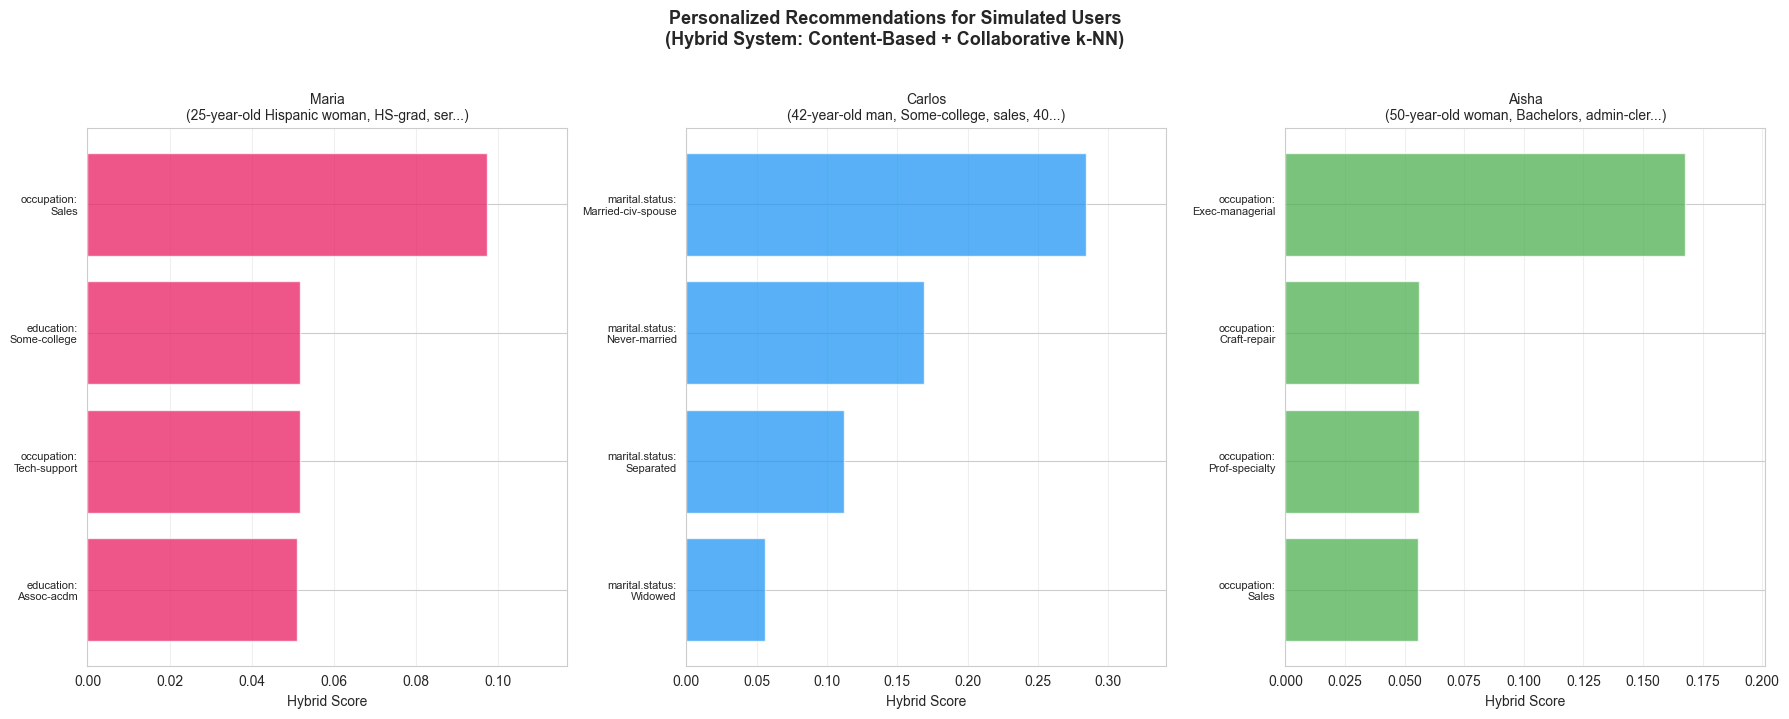


SUMMARY: Key Recommended Trajectories by User

User       Top 1 Recommendation                Top 2 Recommendation                Top 3 Recommendation               
-------------------------------------------------------------------------------------------------------------------
Maria      occupation→Sales                    education→Some-college              occupation→Tech-support            
Carlos     marital.status→Married-civ-spo      marital.status→Never-married        marital.status→Separated           
Aisha      occupation→Exec-managerial          occupation→Craft-repair             occupation→Prof-specialty          

INSIGHT: The system adapts its recommendations to each user's unique context.
  - Maria (young, HS-grad) → likely recommended: higher education + different occupation
  - Carlos (mid-age, some college) → likely recommended: occupation change + more hours
  - Aisha (older, Bachelors) → likely recommended: occupation/relationship trajectory shift


In [14]:
## ============================================================
## 5.2 Visualize Simulated User Recommendations Comparison
## ============================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 7), sharey=False)

colors_map = {'Maria': '#E91E63', 'Carlos': '#2196F3', 'Aisha': '#4CAF50'}

for ax, (name, recs) in zip(axes, all_simulated_recs.items()):
    acquire_recs = [r for r in recs if r['type'] == 'acquire' and r['hybrid_score'] > 0.05][:8]
    
    features = []
    scores = []
    for rec in acquire_recs:
        feat = rec['feature']
        if '_' in feat:
            parts = feat.split('_', 1)
            readable = f"{parts[0]}:\n{parts[1].replace('_', ' ')}"
        else:
            readable = feat
        features.append(readable)
        scores.append(rec['hybrid_score'])
    
    bars = ax.barh(range(len(features)), scores, color=colors_map[name], alpha=0.75)
    ax.set_yticks(range(len(features)))
    ax.set_yticklabels(features, fontsize=8)
    ax.set_xlabel('Hybrid Score')
    ax.set_title(f'{name}\n({simulated_profiles[name]["description"][:40]}...)', fontsize=10)
    ax.invert_yaxis()
    ax.grid(axis='x', alpha=0.3)
    ax.set_xlim(0, max(scores) * 1.2 if scores else 1)

plt.suptitle('Personalized Recommendations for Simulated Users\n(Hybrid System: Content-Based + Collaborative k-NN)', 
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# --- Summary table comparing key recommendations ---
print("\n" + "="*80)
print("SUMMARY: Key Recommended Trajectories by User")
print("="*80)
print(f"\n{'User':<10} {'Top 1 Recommendation':<35} {'Top 2 Recommendation':<35} {'Top 3 Recommendation':<35}")
print("-"*115)

for name, recs in all_simulated_recs.items():
    top_recs = [r for r in recs if r['type'] == 'acquire'][:3]
    rec_names = []
    for r in top_recs:
        feat = r['feature']
        if '_' in feat:
            readable = f"{feat.split('_',1)[0]}→{feat.split('_',1)[1][:15]}"
        else:
            readable = feat[:20]
        rec_names.append(readable)
    while len(rec_names) < 3:
        rec_names.append("—")
    print(f"{name:<10} {rec_names[0]:<35} {rec_names[1]:<35} {rec_names[2]:<35}")

print("\n" + "="*80)
print("INSIGHT: The system adapts its recommendations to each user's unique context.")
print("  - Maria (young, HS-grad) → likely recommended: higher education + different occupation")
print("  - Carlos (mid-age, some college) → likely recommended: occupation change + more hours")  
print("  - Aisha (older, Bachelors) → likely recommended: occupation/relationship trajectory shift")
print("="*80)
